In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LinearRegression, Lasso, Ridge

from sklearn.preprocessing import StandardScaler

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
import pandas as pd

df = pd.read_csv("housing.csv")

#linear

In [8]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

X = df.drop("Price", axis=1)
y = df["Price"]

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Model
model = LinearRegression()
model.fit(X_train, y_train)

# Prediction
y_pred = model.predict(X_test)

# Metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
accuracy = r2 * 100

print("Linear Regression")
print()
print("MAE:", mae)
print("MSE:", mse)
print("R2 Score:", r2)
print("Accuracy:", accuracy)

Linear Regression

MAE: 30.155428223440406
MSE: 945.2406703679085
R2 Score: 0.9859339185957157
Accuracy: 98.59339185957157


#L1(Lasso)

In [10]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

model = Lasso(alpha=1.0)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
accuracy = r2 * 100

print("L1 (Lasso)")
print()
print("MAE:", mae)
print("MSE:", mse)
print("R2 Score:", r2)
print("Accuracy:", accuracy)

L1 (Lasso)

MAE: 30.065901562627953
MSE: 971.020240905656
R2 Score: 0.9855502940341421
Accuracy: 98.55502940341421


In [25]:
# Coefficients
coef = pd.Series(model.coef_, index=X.columns)
print("Lasso Coefficients:\n", coef)

Lasso Coefficients:
 Size        100.640968
Bedrooms    105.801587
Age           1.329313
Distance    -29.319607
dtype: float64


#L2(Ridge)

In [30]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)

y_pred = ridge.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
accuracy = r2 * 100

print("L2 (Ridge)")
print()
print("MAE:", mae)
print("MSE:", mse)
print("R2 Score:", r2)
print("Accuracy:", accuracy)

L2 (Ridge)

MAE: 34.496146845818465
MSE: 1332.8494061790839
R2 Score: 0.9801659314556684
Accuracy: 98.01659314556684


In [31]:
# Coefficients
coef = pd.Series(ridge.coef_, index=X.columns)
print("Ridge Coefficients:\n", coef)

Ridge Coefficients:
 Size        100.664803
Bedrooms    106.531349
Age           1.537463
Distance    -29.215822
dtype: float64


#Comparison

In [21]:
## Scaling for L1 & L2
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [17]:
models = {
    "Linear": LinearRegression(),
    "Lasso (L1)": Lasso(alpha=1.0),
    "Ridge (L2)": Ridge(alpha=1.0)
}

In [18]:
results = []

# Training + Evaluation
for name, model in models.items():

    if name == "Linear":
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
    else:
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)

    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    acc = r2 * 100

    results.append([name, mae, mse, r2, acc])

In [19]:
# Create DataFrame
results_df = pd.DataFrame(results, columns=["Model", "MAE", "MSE", "R2 Score", "Accuracy (%)"])

print(results_df)

        Model        MAE          MSE  R2 Score  Accuracy (%)
0      Linear  30.155428   945.240670  0.985934     98.593392
1  Lasso (L1)  30.163409   967.276360  0.985606     98.560601
2  Ridge (L2)  34.423634  1323.781972  0.980301     98.030086


In [32]:
print(pd.DataFrame({
    "Lasso": model.coef_,
    "Ridge": ridge.coef_
}, index=X.columns))

               Lasso       Ridge
Size      100.640968  100.664803
Bedrooms  105.801587  106.531349
Age         1.329313    1.537463
Distance  -29.319607  -29.215822


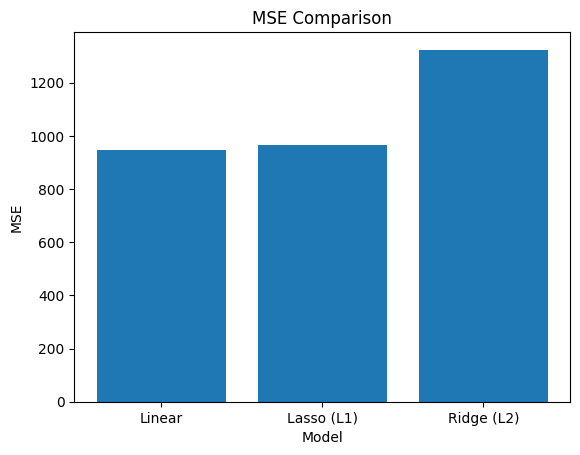

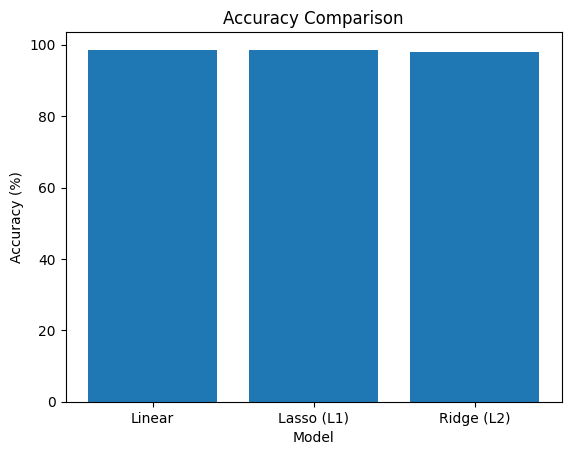

In [23]:
import pandas as pd
import matplotlib.pyplot as plt

#  MSE Graph
plt.figure()
plt.bar(results_df["Model"], results_df["MSE"])
plt.title("MSE Comparison")
plt.xlabel("Model")
plt.ylabel("MSE")
plt.show()

# Accuracy Graph
plt.figure()
plt.bar(results_df["Model"], results_df["Accuracy (%)"])
plt.title("Accuracy Comparison")
plt.xlabel("Model")
plt.ylabel("Accuracy (%)")
plt.show()

Conclusion:
On this housing dataset, Linear Regression provides a strong baseline but may slightly overfit. Ridge (L2) performs the most stable and gives better generalization by controlling coefficient values. Lasso (L1) simplifies the model by reducing some feature impacts, but may slightly reduce performance compared to Ridge.

Therefore,Ridge is the best choice for this dataset, while Lasso helps in feature selection.